# Dataset Explorer

Explora la ultima sesion guardada en `dataset/`, revisa el archivo generado, los electrodos detectados, el flujo de trials y una grafica simple del EEG.

In [2]:
from pathlib import Path
import json
import csv
import numpy as np
import matplotlib.pyplot as plt

DATASET_DIR = Path('../dataset')
summary_files = sorted(DATASET_DIR.rglob('*_summary.json'), key=lambda p: p.stat().st_mtime, reverse=True)
summary_files[:5]

[WindowsPath('../dataset/motor_imagery/MI-01-02-10-290326_summary.json')]

In [3]:
if not summary_files:
    raise FileNotFoundError('No se encontraron archivos *_summary.json en dataset/.')

latest_summary = summary_files[0]
with latest_summary.open('r', encoding='utf-8') as handle:
    summary = json.load(handle)

summary

{'backend': 'xdf',
 'recording_path': 'C:\\Proyects\\BCI\\dataset\\motor_imagery\\MI-01-02-10-290326.xdf',
 'stream_name': 'UN-2019.06.47',
 'stream_type': 'Data',
 'channel_labels': ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'Oz', 'PO8']}

In [4]:
recording_path = Path(summary['recording_path'])
print('Resumen:', latest_summary)
print('Archivo principal:', recording_path)
print('Backend:', summary.get('backend'))
print('Stream EEG:', summary.get('stream_name'))
print('Electrodos:', ', '.join(summary.get('channel_labels', [])))

Resumen: ..\dataset\motor_imagery\MI-01-02-10-290326_summary.json
Archivo principal: C:\Proyects\BCI\dataset\motor_imagery\MI-01-02-10-290326.xdf
Backend: xdf
Stream EEG: UN-2019.06.47
Electrodos: Fz, C3, Cz, C4, Pz, PO7, Oz, PO8


In [5]:
def extract_trial_flow_from_csv(csv_path):
    flow = []
    seen = set()
    with csv_path.open('r', encoding='utf-8', newline='') as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            trial = row.get('trial', '').strip()
            marker = row.get('marker', '').strip()
            if not trial or not marker.startswith('MI_'):
                continue
            key = (int(trial), marker)
            if key in seen:
                continue
            seen.add(key)
            flow.append(key)
    return sorted(flow, key=lambda item: item[0])

def load_xdf_streams(xdf_path):
    import pyxdf
    streams, _ = pyxdf.load_xdf(str(xdf_path))
    return streams

def extract_trial_flow_from_xdf_streams(streams):
    marker_stream = None
    for stream in streams:
        if stream['info']['type'][0] == 'Markers':
            marker_stream = stream
            break
    if marker_stream is None:
        return []
    markers = [str(sample[0]) for sample in marker_stream['time_series'] if sample]
    flow = []
    current_trial = None
    pending_motor_marker = None
    for marker in markers:
        if marker.startswith('TRIAL_'):
            try:
                current_trial = int(marker.split('_')[1])
            except ValueError:
                current_trial = None
            if pending_motor_marker is not None and current_trial is not None:
                flow.append((current_trial, pending_motor_marker))
                pending_motor_marker = None
            continue
        if not marker.startswith('MI_'):
            continue
        if current_trial is not None:
            flow.append((current_trial, marker))
            current_trial = None
        else:
            pending_motor_marker = marker
    deduped = []
    seen = set()
    for item in flow:
        if item in seen:
            continue
        seen.add(item)
        deduped.append(item)
    return sorted(deduped, key=lambda item: item[0])

In [6]:
suffix = recording_path.suffix.lower()
streams = None
if suffix == '.csv':
    trial_flow = extract_trial_flow_from_csv(recording_path)
elif suffix == '.xdf':
    streams = load_xdf_streams(recording_path)
    trial_flow = extract_trial_flow_from_xdf_streams(streams)
else:
    trial_flow = []

trial_flow

found likely XDF file corruption (unpack requires a buffer of 8 bytes), scanning forward to next boundary chunk.


[(2, 'MI_RIGHT'),
 (3, 'MI_LEFT'),
 (4, 'MI_LEFT'),
 (5, 'MI_LEFT'),
 (6, 'MI_LEFT'),
 (7, 'MI_RIGHT'),
 (8, 'MI_LEFT'),
 (9, 'MI_RIGHT'),
 (10, 'MI_RIGHT')]

In [7]:
for trial, marker in trial_flow:
    print(f'Trial {trial}: {marker}')

Trial 2: MI_RIGHT
Trial 3: MI_LEFT
Trial 4: MI_LEFT
Trial 5: MI_LEFT
Trial 6: MI_LEFT
Trial 7: MI_RIGHT
Trial 8: MI_LEFT
Trial 9: MI_RIGHT
Trial 10: MI_RIGHT


In [8]:
if streams is not None:
    marker_stream = next((s for s in streams if s['info']['type'][0] == 'Markers'), None)
    if marker_stream is not None:
        marker_preview = [str(sample[0]) for sample in marker_stream['time_series'][:30] if sample]
        marker_preview
    else:
        print('No se encontro stream de markers.')

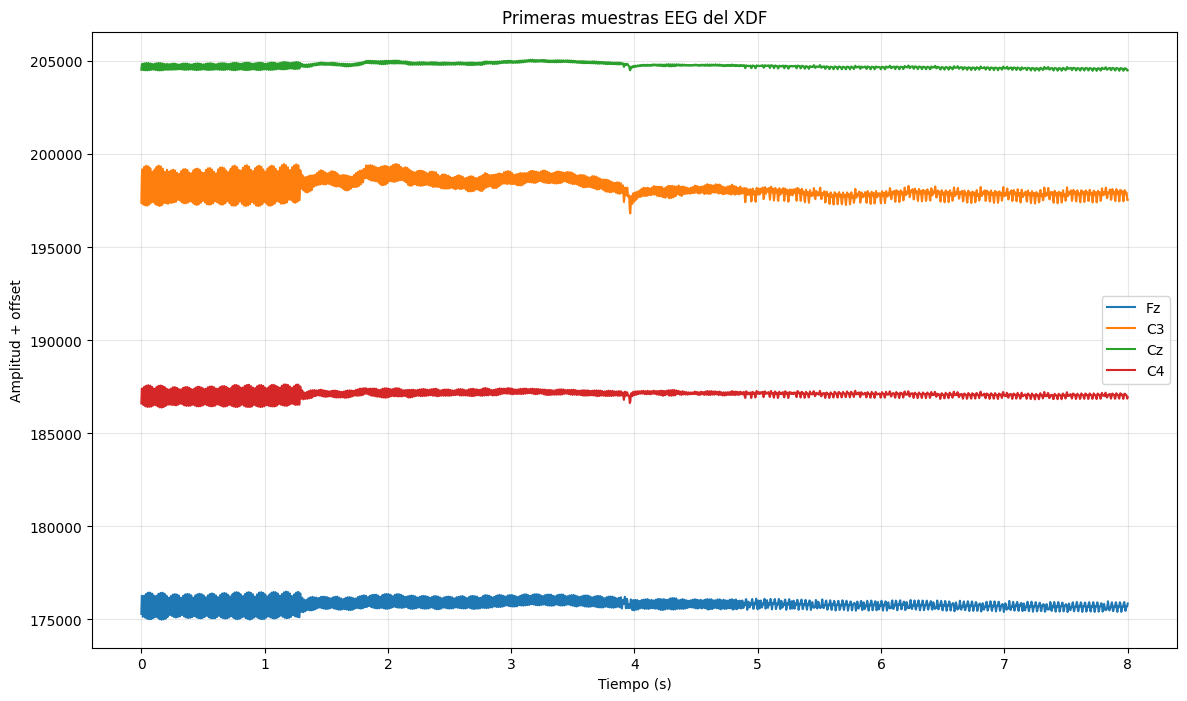

In [9]:
if streams is not None:
    eeg_stream = next((s for s in streams if s['info']['type'][0] in ['Data', 'EEG']), None)
    if eeg_stream is None:
        print('No se encontro stream EEG en el XDF.')
    else:
        data = np.asarray(eeg_stream['time_series'], dtype=float)
        times = np.asarray(eeg_stream['time_stamps'], dtype=float)
        labels = summary.get('channel_labels', [])
        if data.size == 0:
            print('No hay muestras EEG para graficar.')
        else:
            max_channels = min(4, data.shape[1])
            window = min(len(times), 2000)
            plt.figure(figsize=(14, 8))
            for idx in range(max_channels):
                std = np.nanstd(data[:window, idx])
                offset = idx * (std * 4 if std > 0 else 100)
                channel_name = labels[idx] if idx < len(labels) else f'ch{idx+1}'
                plt.plot(times[:window] - times[0], data[:window, idx] + offset, label=channel_name)
            plt.title('Primeras muestras EEG del XDF')
            plt.xlabel('Tiempo (s)')
            plt.ylabel('Amplitud + offset')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

## Comparacion izquierda vs derecha

Esta seccion extrae epochs de 5 segundos desde cada marker `MI_LEFT` y `MI_RIGHT`, y compara sus curvas promedio en canales como `C3` y `C4` si estan disponibles.

In [10]:
def collect_marker_events(streams):
    marker_stream = next((s for s in streams if s['info']['type'][0] == 'Markers'), None)
    if marker_stream is None:
        return []
    events = []
    for ts, sample in zip(marker_stream['time_stamps'], marker_stream['time_series']):
        if sample:
            events.append((float(ts), str(sample[0])))
    return events

def extract_epochs_by_marker(eeg_times, eeg_data, events, marker_name, epoch_seconds=5.0):
    epochs = []
    for ts, marker in events:
        if marker != marker_name:
            continue
        start_idx = np.searchsorted(eeg_times, ts)
        end_idx = np.searchsorted(eeg_times, ts + epoch_seconds)
        if end_idx > start_idx:
            epochs.append(eeg_data[start_idx:end_idx])
    return epochs

def trim_epochs(epochs):
    if not epochs:
        return np.array([])
    min_len = min(epoch.shape[0] for epoch in epochs)
    trimmed = np.array([epoch[:min_len] for epoch in epochs])
    return trimmed

def choose_channels(labels, eeg_data):
    preferred = ['C3', 'C4']
    chosen = []
    for name in preferred:
        if name in labels:
            chosen.append(labels.index(name))
    if not chosen:
        chosen = list(range(min(2, eeg_data.shape[1])))
    return chosen

In [11]:
if streams is None:
    print('Esta comparacion requiere un archivo XDF.')
else:
    eeg_stream = next((s for s in streams if s['info']['type'][0] in ['Data', 'EEG']), None)
    if eeg_stream is None:
        print('No se encontro stream EEG.')
    else:
        eeg_data = np.asarray(eeg_stream['time_series'], dtype=float)
        eeg_times = np.asarray(eeg_stream['time_stamps'], dtype=float)
        labels = summary.get('channel_labels', [])
        events = collect_marker_events(streams)
        left_epochs = trim_epochs(extract_epochs_by_marker(eeg_times, eeg_data, events, 'MI_LEFT'))
        right_epochs = trim_epochs(extract_epochs_by_marker(eeg_times, eeg_data, events, 'MI_RIGHT'))
        chosen_channels = choose_channels(labels, eeg_data)
        print('Canales comparados:', [labels[idx] if idx < len(labels) else f'ch{idx+1}' for idx in chosen_channels])
        print('Epochs LEFT:', 0 if left_epochs.size == 0 else left_epochs.shape[0])
        print('Epochs RIGHT:', 0 if right_epochs.size == 0 else right_epochs.shape[0])

Canales comparados: ['C3', 'C4']
Epochs LEFT: 5
Epochs RIGHT: 5


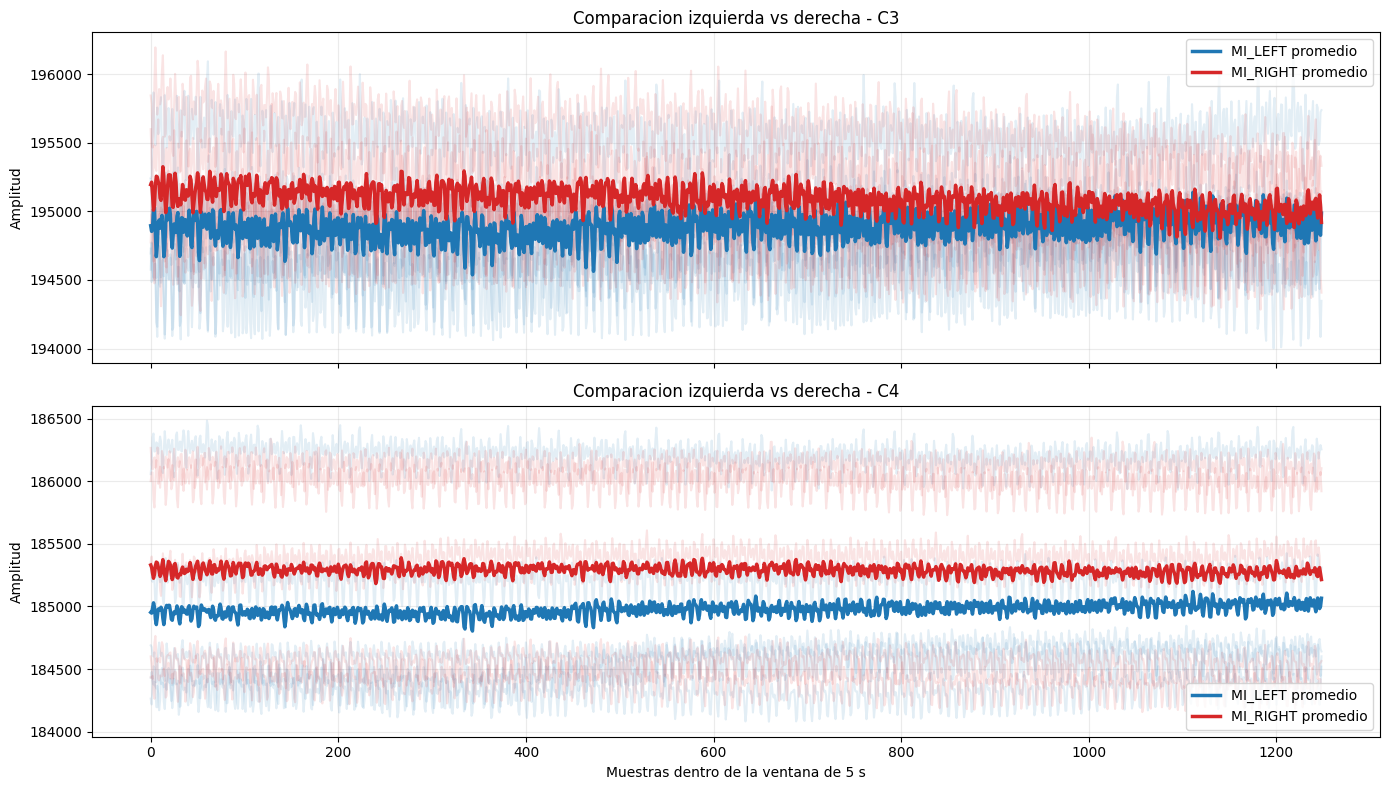

In [12]:
if streams is not None and 'left_epochs' in locals() and left_epochs.size and right_epochs.size:
    min_len = min(left_epochs.shape[1], right_epochs.shape[1])
    left_epochs = left_epochs[:, :min_len, :]
    right_epochs = right_epochs[:, :min_len, :]
    time_axis = np.arange(min_len)

    fig, axes = plt.subplots(len(chosen_channels), 1, figsize=(14, 4 * len(chosen_channels)), sharex=True)
    if len(chosen_channels) == 1:
        axes = [axes]

    for ax, channel_idx in zip(axes, chosen_channels):
        channel_name = labels[channel_idx] if channel_idx < len(labels) else f'ch{channel_idx+1}'
        left_mean = left_epochs[:, :, channel_idx].mean(axis=0)
        right_mean = right_epochs[:, :, channel_idx].mean(axis=0)

        for epoch in left_epochs[:, :, channel_idx]:
            ax.plot(time_axis, epoch, color='tab:blue', alpha=0.12)
        for epoch in right_epochs[:, :, channel_idx]:
            ax.plot(time_axis, epoch, color='tab:red', alpha=0.12)

        ax.plot(time_axis, left_mean, color='tab:blue', linewidth=2.5, label='MI_LEFT promedio')
        ax.plot(time_axis, right_mean, color='tab:red', linewidth=2.5, label='MI_RIGHT promedio')
        ax.set_title(f'Comparacion izquierda vs derecha - {channel_name}')
        ax.set_ylabel('Amplitud')
        ax.grid(True, alpha=0.25)
        ax.legend()

    axes[-1].set_xlabel('Muestras dentro de la ventana de 5 s')
    plt.tight_layout()
    plt.show()
else:
    print('No hay suficientes epochs LEFT/RIGHT para comparar.')